Load modules and initialize plotting parameters

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from irispy.io import read_files
import importlib 
from astropy.time import Time
import astropy.units as u 

import sji_support as sjis

font = {'weight' : 'normal', 'size'   : 18}
plt.rc('font', **font)

%matplotlib widget

Load test SJI file to the parent folder. Download at https://www.lmsal.com/solarsoft/irisa/data/level2_compressed/2024/07/21/20240721_090637_4204700237/iris_l2_20240721_090637_4204700237_SJI_1330_t000.fits.gz

This might take a minute, depending on the size of the SJI file.

In [ ]:
fitsfile = 'iris_l2_20240721_090637_4204700237_SJI_1330_t000.fits'

sjifile = read_files(fitsfile)
(time_sji,) = sjifile.axis_world_coords("time")

Choose target time for plotting of the SJI image.

In [5]:
time_plot = '2024-07-21T11:08'
target_time = Time(time_plot, scale="utc", format="isot")
idx = int(np.argmin(np.abs(time_sji - target_time)))

Load the map corresponding to the time

In [6]:
sjimap = sjifile.to_maps(idx)

Define saturation, xrange and yrange

In [7]:
cmap = 'irissjiFUV'

xrange = [291, 345]
yrange = [-229, -171]

sat = [1e0, 5e2]
tickinterval = 20

Define plotting parameters of the map

In [9]:
plot_parameters = {
    "cmap": cmap,
    "sat": sat,
    "xrange": xrange,
    "yrange": yrange, 
    "tickinterval":10
}

Define random Y position along the slit to plot on the map

In [11]:
ypos = -202

line_x1 = (xrange[0]*u.arcsec).to(u.deg).value
line_x2 = (xrange[1]*u.arcsec).to(u.deg).value
line_y = (ypos*u.arcsec).to(u.deg).value

Plotting as a sunpy map. Most reliable in terms of co-alignment with spectroscopic data (assuming coordinates are extracted from WCS). Plotting anything else is clumsy.

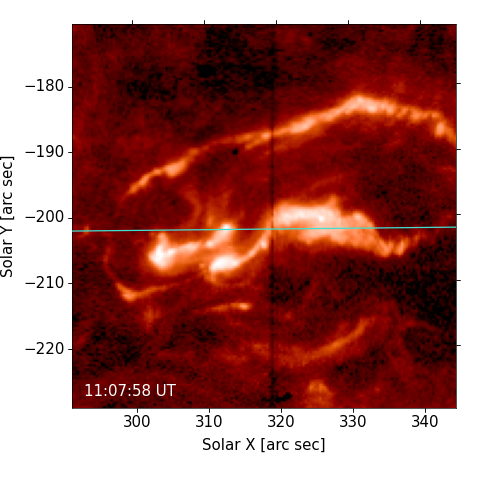

In [13]:
fig, ax, im = sjis.plot_sji(sjimap, mode = 'sunpymap', **plot_parameters)

ax.plot([line_x1, line_x2], [line_y, line_y], transform=ax.get_transform('world'), color = 'turquoise')

plt.savefig('sjisnap_SM.jpg', dpi = 100)

Plotting the sunpy map onto a simple grid of coordinates (with left-right, top-bottom) orientation. Coordinates are the same as those in IDL maps, but the image does not account for the FOV rotation. 

Advantage of this approach is that replotting veritually anything on the background map is easy and straightforward.

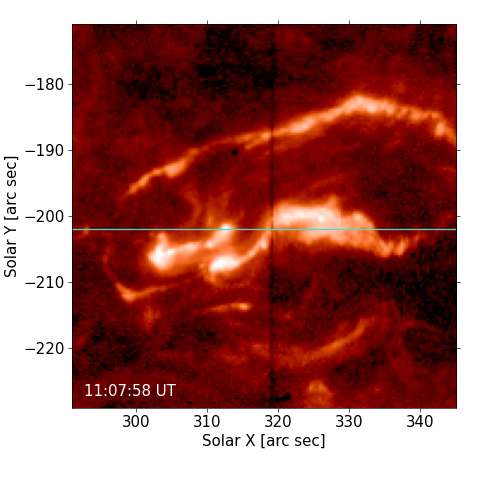

In [14]:
fig, ax, im = sjis.plot_sji(sjimap, mode = 'extent', **plot_parameters)

ax.axhline(ypos, color = 'turquoise')

plt.savefig('sjisnap_extent.jpg', dpi = 100)

# Optional correction for differential rotation

Use with caution, does not return results consistent with IDL! Derotate the map to the time of choosing using the default 'Howard' model for differential rotation.

In [15]:
drot_map = sjis.diffrot(sjimap, '2024-07-21T11:00')

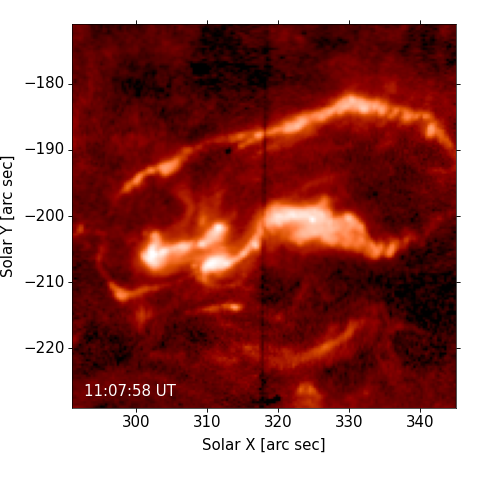

In [16]:
fig, ax, im = sjis.plot_sji(drot_map, mode = 'sunpymap', **plot_parameters)